# Cubic Zirconia Price Prediction

## Project Overview

This project aims to predict cubic zirconia prices based on product attributes such as carat, cut, color, clarity, depth, table, and physical dimensions.

I follow a complete data workflow: data loading, ETL/data cleaning, exploratory data analysis, feature engineering, regression modeling, model evaluation, and final interpretation.

The main objective is not only to build a prediction model, but also to understand which product characteristics are most related to price.

## 1. Import Libraries

I import the libraries needed for data manipulation, visualization, machine learning, model evaluation, and saving project outputs.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import os

## 2. Data Loading

I load the raw dataset from a CSV file. At this stage, I keep the original data unchanged so that every cleaning step can be traced clearly.

In [2]:
df = pd.read_csv("data/raw/cubic_zirconia.csv")

df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,x,y,z,price
0,1,0.30,Ideal,E,SI1,62.1,58.0,4.27,4.29,2.66,499
1,2,0.33,Premium,G,IF,60.8,58.0,4.42,4.46,2.70,984
2,3,0.90,Very Good,E,VVS2,62.2,60.0,6.04,6.12,3.78,6289
3,4,0.42,Ideal,F,VS1,61.6,56.0,4.82,4.80,2.96,1082
4,5,0.31,Ideal,F,VVS1,60.4,59.0,4.35,4.43,2.65,779


## 3. Data Understanding

Before cleaning or modeling, I check the dataset structure, including the number of rows and columns, data types, missing values, duplicated records, and basic summary statistics.

In [3]:
print("Dataset shape:", df.shape)

df.info()

Dataset shape: (26967, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26967 entries, 0 to 26966
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  26967 non-null  int64  
 1   carat       26967 non-null  float64
 2   cut         26967 non-null  object 
 3   color       26967 non-null  object 
 4   clarity     26967 non-null  object 
 5   depth       26270 non-null  float64
 6   table       26967 non-null  float64
 7   x           26967 non-null  float64
 8   y           26967 non-null  float64
 9   z           26967 non-null  float64
 10  price       26967 non-null  int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 2.3+ MB


The `describe()` function summarizes numerical columns, including average values, minimum, maximum, and quartiles. This gives a first look at the range and distribution of variables such as carat, depth, table, dimensions, and price.

In [4]:
df.describe()

,Unnamed: 0,carat,depth,table,x,y,z,price
count,26967.000000,26967.000000,26270.000000,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000
mean,13484.000000,0.798375,61.745147,57.456080,5.729854,5.733569,3.538057,3939.518115
std,7784.846691,0.477745,1.412860,2.232068,1.128516,1.166058,0.720624,4024.864666
min,1.000000,0.200000,50.800000,49.000000,0.000000,0.000000,0.000000,326.000000
25%,6742.500000,0.400000,61.000000,56.000000,4.710000,4.710000,2.900000,945.000000
50%,13484.000000,0.700000,61.800000,57.000000,5.690000,5.710000,3.520000,2375.000000
75%,20225.500000,1.050000,62.500000,59.000000,6.550000,6.540000,4.040000,5360.000000
max,26967.000000,4.500000,73.600000,79.000000,10.230000,58.900000,31.800000,18818.000000


I check missing values in each column. Missing values need to be handled before modeling because most machine learning models cannot process missing data directly.

In [5]:
df.isna().sum()

Unnamed: 0      0
carat           0
cut             0
color           0
clarity         0
depth         697
table           0
x               0
y               0
z               0
price           0
dtype: int64

I also check duplicated records because repeated rows can bias the analysis and model training process.

In [6]:
df.duplicated().sum()

np.int64(0)

## 4. ETL and Data Cleaning

The ETL process includes:

- **Extract:** loading the raw CSV file
- **Transform:** cleaning the data and creating new useful features
- **Load:** saving the cleaned dataset for analysis and modeling

This process makes the project more structured and easier to reproduce.

### 4.1 Create a Copy of the Raw Dataset

I create a copy of the original dataset before cleaning. This keeps the raw data unchanged and allows all transformations to be applied on a separate cleaned version.

In [7]:
df_clean = df.copy()

df_clean.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,x,y,z,price
0,1,0.30,Ideal,E,SI1,62.1,58.0,4.27,4.29,2.66,499
1,2,0.33,Premium,G,IF,60.8,58.0,4.42,4.46,2.70,984
2,3,0.90,Very Good,E,VVS2,62.2,60.0,6.04,6.12,3.78,6289
3,4,0.42,Ideal,F,VS1,61.6,56.0,4.82,4.80,2.96,1082
4,5,0.31,Ideal,F,VVS1,60.4,59.0,4.35,4.43,2.65,779


### 4.2 Remove Unnecessary Index Column

The column `Unnamed: 0` appears to be an index column created during CSV export. It does not provide useful information for analysis or modeling, so I remove it.

In [8]:
if "Unnamed: 0" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Unnamed: 0"])

df_clean.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.30,Ideal,E,SI1,62.1,58.0,4.27,4.29,2.66,499
1,0.33,Premium,G,IF,60.8,58.0,4.42,4.46,2.70,984
2,0.90,Very Good,E,VVS2,62.2,60.0,6.04,6.12,3.78,6289
3,0.42,Ideal,F,VS1,61.6,56.0,4.82,4.80,2.96,1082
4,0.31,Ideal,F,VVS1,60.4,59.0,4.35,4.43,2.65,779


### 4.3 Remove Duplicated Records

I remove duplicated rows to avoid giving repeated observations extra weight during analysis and model training.

In [9]:
before_rows = df_clean.shape[0]

df_clean = df_clean.drop_duplicates()

after_rows = df_clean.shape[0]

print("Rows before removing duplicates:", before_rows)
print("Rows after removing duplicates:", after_rows)
print("Duplicates removed:", before_rows - after_rows)

Rows before removing duplicates: 26967
Rows after removing duplicates: 26933
Duplicates removed: 34


### 4.4 Handle Missing Values

I check missing values again after removing duplicates. If `depth` contains missing values, I fill them with the median value.

I use the median instead of the mean because the median is less affected by extreme values.

In [10]:
df_clean.isna().sum()

carat        0
cut          0
color        0
clarity      0
depth      697
table        0
x            0
y            0
z            0
price        0
dtype: int64

In [11]:
if df_clean["depth"].isna().sum() > 0:
    df_clean["depth"] = df_clean["depth"].fillna(df_clean["depth"].median())

df_clean.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64

### 4.5 Check Invalid Dimension Values

The variables `x`, `y`, and `z` represent the physical dimensions of the stone. Values less than or equal to zero are not realistic, so I identify and remove them.

In [12]:
invalid_dimensions = df_clean[
    (df_clean["x"] <= 0) | 
    (df_clean["y"] <= 0) | 
    (df_clean["z"] <= 0)
]

invalid_dimensions.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
5821,0.71,Good,F,SI2,64.1,60.0,0.00,0.00,0.0,2130
6034,2.02,Premium,H,VS2,62.7,53.0,8.02,7.95,0.0,18207
10827,2.20,Premium,H,SI1,61.2,59.0,8.42,8.37,0.0,17265
12498,2.18,Premium,H,SI2,59.4,61.0,8.49,8.45,0.0,12631
12689,1.10,Premium,G,SI2,63.0,59.0,6.50,6.47,0.0,3696


In [13]:
print("Number of rows with invalid dimensions:", invalid_dimensions.shape[0])

Number of rows with invalid dimensions: 8


### 4.6 Remove Invalid Dimension Records

I remove rows with invalid dimensions because a physical product cannot have zero or negative length, width, or depth.

In [14]:
before_rows = df_clean.shape[0]

df_clean = df_clean[
    (df_clean["x"] > 0) & 
    (df_clean["y"] > 0) & 
    (df_clean["z"] > 0)
]

after_rows = df_clean.shape[0]

print("Rows before removing invalid dimensions:", before_rows)
print("Rows after removing invalid dimensions:", after_rows)
print("Rows removed:", before_rows - after_rows)

Rows before removing invalid dimensions: 26933
Rows after removing invalid dimensions: 26925
Rows removed: 8


### 4.7 Create a New Feature: Volume

I create a new feature called `volume` by multiplying `x`, `y`, and `z`.

This feature represents the approximate physical size of each stone and may help the model better capture the relationship between stone size and price.

Since `volume` is derived from `x`, `y`, and `z`, it may be correlated with the original dimension variables. I keep it in the model as an engineered feature, but I interpret it together with other size-related variables.

In [15]:
df_clean["volume"] = df_clean["x"] * df_clean["y"] * df_clean["z"]

df_clean.head()

,carat,cut,color,clarity,depth,table,x,y,z,price,volume
0,0.30,Ideal,E,SI1,62.1,58.0,4.27,4.29,2.66,499,48.726678
1,0.33,Premium,G,IF,60.8,58.0,4.42,4.46,2.70,984,53.225640
2,0.90,Very Good,E,VVS2,62.2,60.0,6.04,6.12,3.78,6289,139.726944
3,0.42,Ideal,F,VS1,61.6,56.0,4.82,4.80,2.96,1082,68.482560
4,0.31,Ideal,F,VVS1,60.4,59.0,4.35,4.43,2.65,779,51.066825


### 4.8 Save Cleaned Dataset

I save the cleaned dataset into a processed data folder. This separates raw data from cleaned data and makes the workflow more organized.

In [16]:
os.makedirs("data/processed", exist_ok=True)

df_clean.to_csv("data/processed/cubic_zirconia_cleaned.csv", index=False)

print("Cleaned data saved successfully.")

Cleaned data saved successfully.


## 5. Exploratory Data Analysis

In this section, I explore the cleaned dataset to understand price distribution, relationships between variables, and potential price drivers.

I also save key charts into the `outputs/figures` folder so they can be used later in the GitHub README.

In [17]:
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

### 5.1 Price Distribution

This chart shows how cubic zirconia prices are distributed. It helps identify whether most products are concentrated in a lower price range or spread evenly across different price levels.

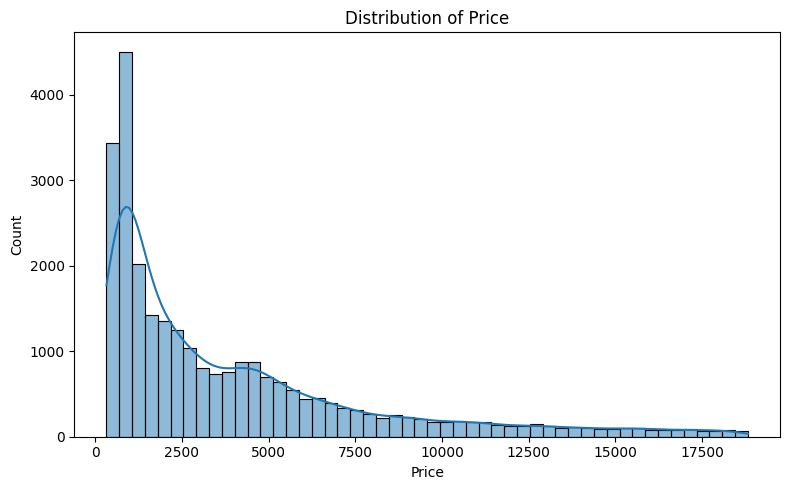

Price skewness: 1.619054607755582


In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["price"], bins=50, kde=True)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/figures/price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Price skewness:", df_clean["price"].skew())

The price distribution is expected to be right-skewed, meaning most stones are in the lower price range while fewer stones have very high prices. This is common in product pricing datasets where premium items appear less frequently.

### 5.2 Carat vs Price

This scatter plot shows the relationship between carat and price. Carat is expected to be one of the strongest price drivers because it represents the weight of the stone.

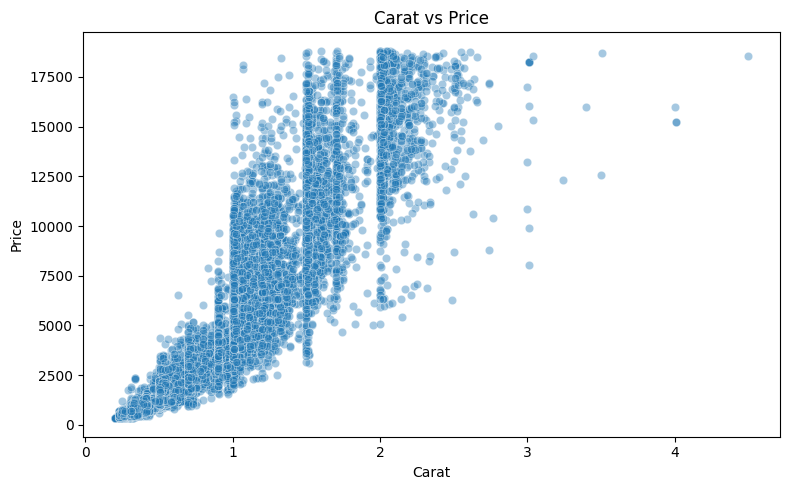

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x="carat", y="price", alpha=0.4)
plt.title("Carat vs Price")
plt.xlabel("Carat")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig("outputs/figures/carat_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()

There is generally a positive relationship between carat and price. As carat increases, price tends to increase as well. However, the relationship may not be perfectly linear because price can also depend on cut, color, clarity, and dimensions.

### 5.3 Correlation Heatmap

The correlation heatmap shows the relationship between numerical variables. This helps identify which features are most strongly associated with price.

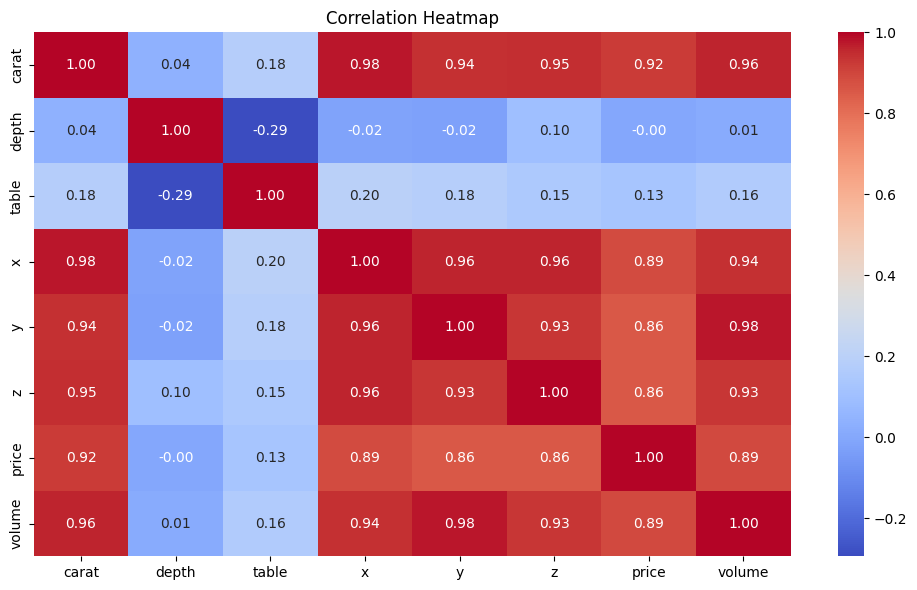

In [20]:
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("outputs/figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

To make the relationship with price easier to read, I sort all numerical features by their correlation with price.

In [21]:
price_corr = numeric_cols.corr()["price"].sort_values(ascending=False)

price_corr

price     1.000000
carat     0.922400
volume    0.888891
x         0.887467
y         0.857255
z         0.855775
table     0.126967
depth    -0.002683
Name: price, dtype: float64

Carat and size-related variables such as `x`, `y`, `z`, and `volume` are expected to have strong correlation with price. This suggests that stone size is a major factor in price prediction.

### 5.4 Price by Cut

This boxplot compares price distribution across different cut categories.

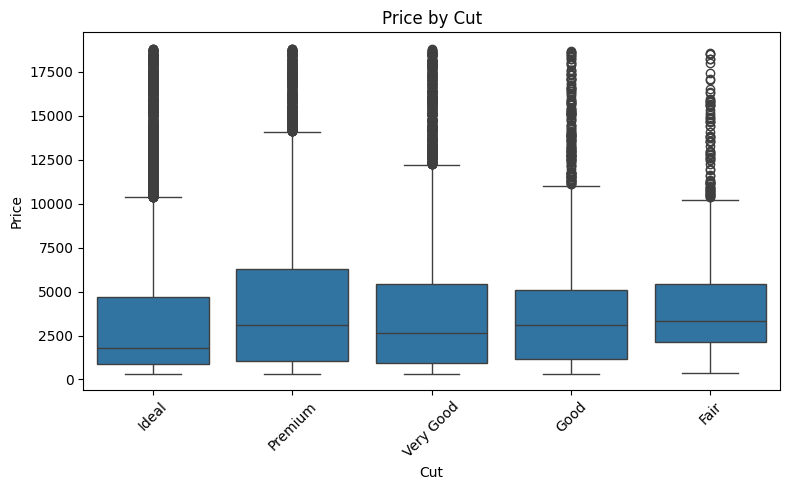

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="cut", y="price")
plt.title("Price by Cut")
plt.xlabel("Cut")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/figures/price_by_cut.png", dpi=300, bbox_inches="tight")
plt.show()

Cut quality can influence price, but the boxplot should be interpreted together with carat and size. A lower cut category may still have a high price if the stone has a larger carat.

### 5.5 Price by Color

This boxplot compares price distribution across different color categories.

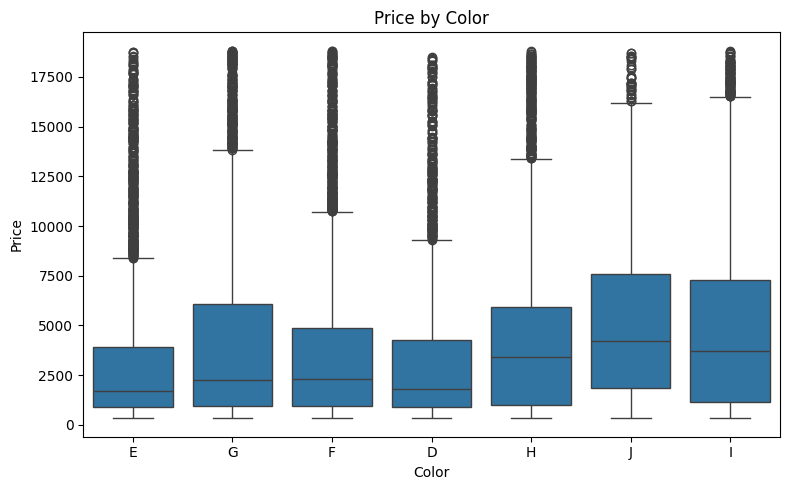

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="color", y="price")
plt.title("Price by Color")
plt.xlabel("Color")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig("outputs/figures/price_by_color.png", dpi=300, bbox_inches="tight")
plt.show()

Color appears to contribute to price differences, but price patterns may also be affected by other attributes such as carat, clarity, and dimensions.

### 5.6 Price by Clarity

This boxplot compares price distribution across different clarity categories.

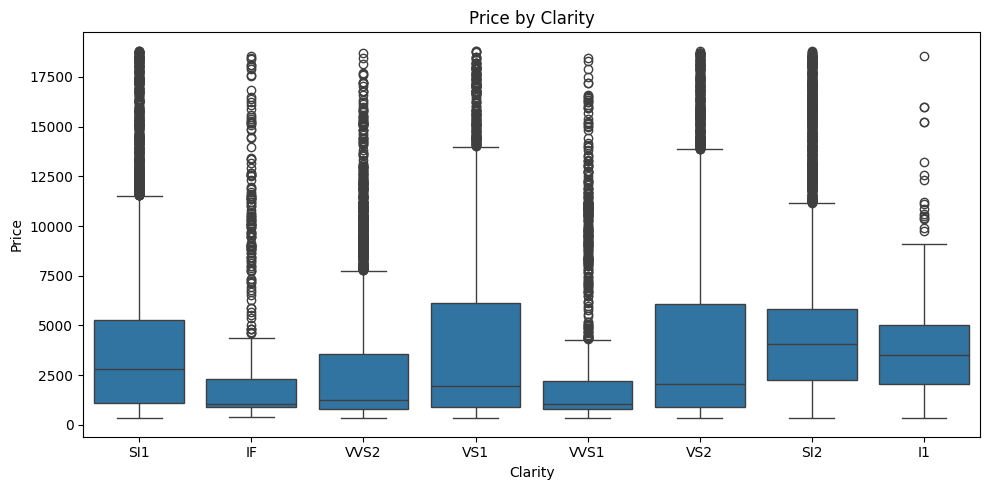

In [24]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x="clarity", y="price")
plt.title("Price by Clarity")
plt.xlabel("Clarity")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig("outputs/figures/price_by_clarity.png", dpi=300, bbox_inches="tight")
plt.show()

Clarity is another quality-related factor that may influence price. However, similar to cut and color, it should not be interpreted alone because price is affected by multiple variables at the same time.

## 6. Feature Engineering for Machine Learning

Before training machine learning models, I separate the dataset into features and target variable.

- **Features:** product characteristics used to predict price
- **Target:** `price`, the value to be predicted

In [25]:
X = df_clean.drop(columns=["price"])
y = df_clean["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (26925, 10)
Target shape: (26925,)


Categorical variables such as `cut`, `color`, and `clarity` need to be encoded because machine learning models cannot directly understand text categories.

Numerical variables such as `carat`, `depth`, `table`, `x`, `y`, `z`, and `volume` are passed into the model without encoding.

In [26]:
categorical_features = ["cut", "color", "clarity"]

numeric_features = [
    "carat", 
    "depth", 
    "table", 
    "x", 
    "y", 
    "z", 
    "volume"
]

I create a preprocessing pipeline using `ColumnTransformer`.

- One-Hot Encoding is applied to categorical features.
- Numerical features are passed through without transformation.

This keeps preprocessing and modeling organized in one workflow.

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numeric_features)
    ]
)

## 7. Train-Test Split

I split the dataset into training and testing sets.

- **Training set:** used to train the models
- **Testing set:** used to evaluate model performance on unseen data

An 80/20 split is used in this project.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (21540, 10)
X_test shape: (5385, 10)
y_train shape: (21540,)
y_test shape: (5385,)


## 8. Model Training

I train and compare four regression models:

1. Linear Regression
2. Ridge Regression
3. Random Forest Regressor
4. Gradient Boosting Regressor

Linear Regression and Ridge Regression are used as baseline models. Random Forest and Gradient Boosting are tree-based models that can capture more complex and non-linear relationships.

In [29]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

I train each model using the same preprocessing pipeline and evaluate each model on the same test set. This makes the comparison fair and consistent.

In [30]:
results = []
trained_pipelines = {}
predictions = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_pipelines[model_name] = pipeline
    predictions[model_name] = y_pred

results_df = pd.DataFrame(results).sort_values(by="RMSE")

results_df

,Model,MAE,RMSE,R2
2,Random Forest,291.452399,591.766534,0.978809
3,Gradient Boosting,410.293003,737.175465,0.967115
1,Ridge Regression,743.007350,1129.921354,0.922741
0,Linear Regression,743.298324,1137.417539,0.921712


## 9. Model Evaluation

I evaluate the models using three metrics:

- **MAE:** Mean Absolute Error, showing the average prediction error
- **RMSE:** Root Mean Squared Error, penalizing larger errors more strongly
- **R²:** showing how much variation in price is explained by the model

A better model should have lower MAE and RMSE, and higher R².

In [31]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_pipelines[best_model_name]
best_predictions = predictions[best_model_name]

print("Best model:", best_model_name)

Best model: Random Forest


I select the best model based on the lowest RMSE. RMSE is used here because large pricing errors are more costly and should be penalized more heavily.

### 9.1 Model Comparison Chart

I visualize RMSE by model to compare prediction errors more clearly.

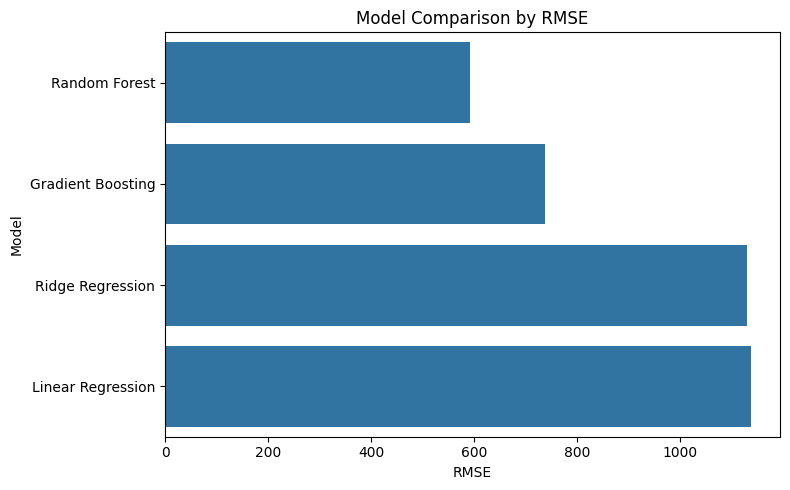

In [32]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="RMSE", y="Model")
plt.title("Model Comparison by RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig("outputs/figures/model_comparison_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

### 9.2 Actual vs Predicted Price

This chart compares actual prices with predicted prices from the best-performing model. A stronger model should have points closer to the diagonal reference line.

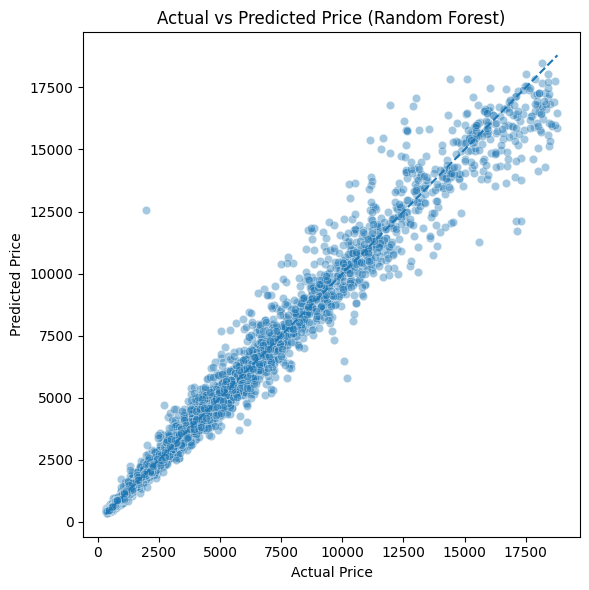

In [33]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=best_predictions, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title(f"Actual vs Predicted Price ({best_model_name})")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.tight_layout()
plt.savefig("outputs/figures/actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Save Model Outputs

I save the model comparison table as a CSV file so it can be reused in the README, report, or portfolio documentation.

In [34]:
results_df.to_csv("outputs/tables/model_comparison.csv", index=False)

print("Model comparison saved successfully.")

Model comparison saved successfully.


I also save the best-performing model as a `.pkl` file. This allows the trained model to be reused later without retraining.

In [35]:
os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/best_cubic_zirconia_price_model.pkl")

print("Best model saved successfully.")

Best model saved successfully.


## 11. Prediction Sample

To better understand model performance, I create a sample table comparing actual prices and predicted prices.

In [36]:
sample_predictions = X_test.copy()
sample_predictions["actual_price"] = y_test
sample_predictions["predicted_price"] = best_model.predict(X_test)
sample_predictions["prediction_error"] = sample_predictions["actual_price"] - sample_predictions["predicted_price"]

sample_predictions.head()

,carat,cut,color,clarity,depth,table,x,y,z,volume,actual_price,predicted_price,prediction_error
20985,0.31,Very Good,D,SI2,62.5,55.0,4.30,4.34,2.70,50.387400,462,459.55,2.45
17851,1.52,Ideal,H,SI1,61.4,55.0,7.38,7.48,4.56,251.722944,10239,10452.64,-213.64
6055,0.38,Ideal,D,VVS2,61.5,57.0,4.63,4.67,2.86,61.839206,1200,1169.50,30.50
4814,0.56,Ideal,G,VS1,62.0,56.0,5.28,5.30,3.28,91.787520,1822,1899.14,-77.14
23486,1.13,Premium,I,VS1,62.2,58.0,6.68,6.63,4.14,183.353976,5316,5429.38,-113.38


The prediction error shows the difference between actual and predicted prices. Smaller errors indicate that the model prediction is closer to the actual price.

In [37]:
sample_predictions.head(100).to_csv("outputs/tables/prediction_sample.csv", index=False)

print("Prediction sample saved successfully.")

Prediction sample saved successfully.


## 12. Feature Importance

For tree-based models such as Random Forest and Gradient Boosting, I use feature importance to understand which variables contribute most to the prediction.

Since some size-related variables are highly correlated, I also check their correlations before interpreting feature importance.

### 12.1 Size-related Feature Correlation

Before interpreting feature importance, I check the relationships between size-related features: `carat`, `x`, `y`, `z`, `volume`, and `price`.

This is important because `volume` is created from `x`, `y`, and `z`, while dimensions are also naturally related to `carat`. If these variables are highly correlated, they should be interpreted as a feature group rather than as fully independent price drivers.

In [38]:
size_features = ["carat", "x", "y", "z", "volume", "price"]

size_corr = df_clean[size_features].corr()
size_corr

,carat,x,y,z,volume,price
carat,1.000000,0.977908,0.942378,0.946774,0.961040,0.922400
x,0.977908,1.000000,0.962510,0.961010,0.941296,0.887467
y,0.942378,0.962510,1.000000,0.932974,0.978724,0.857255
z,0.946774,0.961010,0.932974,1.000000,0.931027,0.855775
volume,0.961040,0.941296,0.978724,0.931027,1.000000,0.888891
price,0.922400,0.887467,0.857255,0.855775,0.888891,1.000000


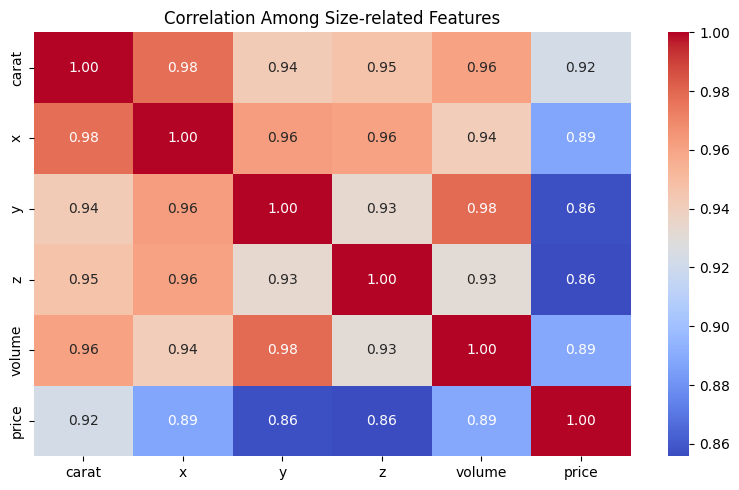

In [39]:
plt.figure(figsize=(8, 5))
sns.heatmap(size_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Among Size-related Features")
plt.tight_layout()
plt.savefig("outputs/figures/size_feature_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

The correlation results show that `carat`, `x`, `y`, `z`, and `volume` are strongly related to each other. Therefore, I interpret them as size and weight-related features rather than separate independent drivers.

This means the main takeaway from feature importance should be that physical size and weight are the strongest predictors of cubic zirconia price.

### 12.2 Extract Feature Importance

If the selected best model supports feature importance, I extract and rank the most important features.

In [40]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

feature_names[:10]

array(['categorical__cut_Fair', 'categorical__cut_Good',
       'categorical__cut_Ideal', 'categorical__cut_Premium',
       'categorical__cut_Very Good', 'categorical__color_D',
       'categorical__color_E', 'categorical__color_F',
       'categorical__color_G', 'categorical__color_H'], dtype=object)

In [41]:
model_step = best_model.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model_step.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    display(feature_importance.head(15))
else:
    print("This model does not provide feature importance.")

,Feature,Importance
26,numerical__volume,0.654753
24,numerical__y,0.121835
20,numerical__carat,0.117544
15,categorical__clarity_SI2,0.019540
12,categorical__clarity_I1,0.013294
14,categorical__clarity_SI1,0.013153
11,categorical__color_J,0.009970
10,categorical__color_I,0.007845
17,categorical__clarity_VS2,0.006393
9,categorical__color_H,0.005139


In [42]:
if hasattr(model_step, "feature_importances_"):
    feature_importance.to_csv("outputs/tables/feature_importance.csv", index=False)
    print("Feature importance saved successfully.")

Feature importance saved successfully.


### 12.3 Visualize Feature Importance

This chart helps visualize which variables have the strongest influence on model predictions.

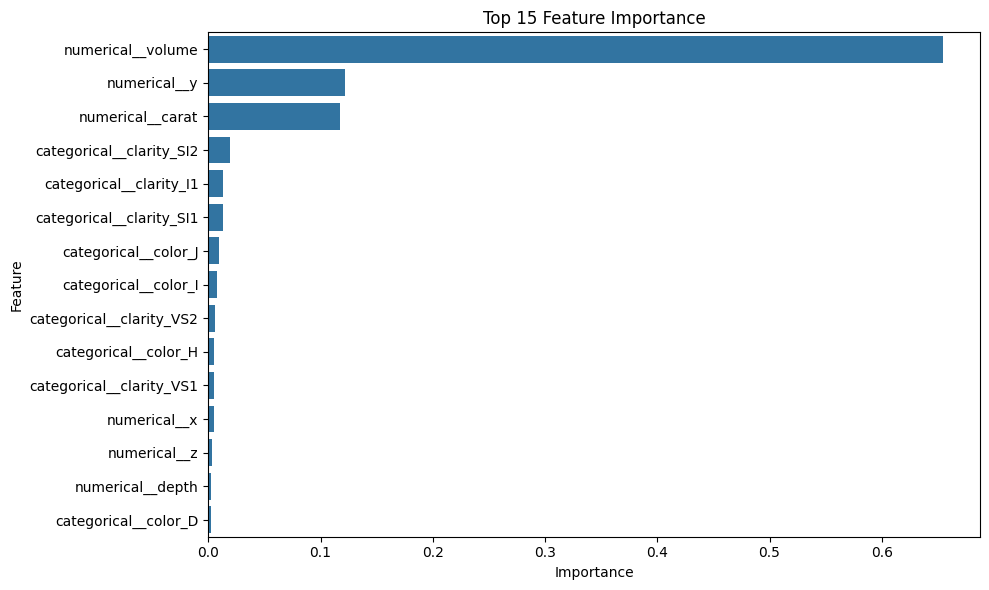

In [43]:
if hasattr(model_step, "feature_importances_"):
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=feature_importance.head(15), 
        x="Importance", 
        y="Feature"
    )
    plt.title("Top 15 Feature Importance")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig("outputs/figures/feature_importance.png", dpi=300, bbox_inches="tight")
    plt.show()

The feature importance results show that size-related features are the strongest predictors of cubic zirconia price. The most important features may include `volume`, `y`, and `carat`, which are all related to the physical size or weight of the stone.

However, these variables should not be interpreted as fully independent effects. The `volume` feature is created from `x`, `y`, and `z`, while the dimensions are also naturally related to `carat`. Therefore, the key takeaway is that size and weight-related features are the dominant drivers of price in this dataset.

Quality-related attributes such as clarity and color also contribute to the prediction, but their importance is lower compared to size-related features.

## 13. Final Summary

In this section, I summarize the full project workflow, best-performing model, and key findings.

In [44]:
print("PROJECT SUMMARY")
print("-" * 50)
print("Dataset after cleaning:", df_clean.shape)
print("Target variable: price")
print("Best model:", best_model_name)

print("\nModel performance:")
display(results_df)

if hasattr(model_step, "feature_importances_"):
    print("\nTop 10 important features:")
    display(feature_importance.head(10))

PROJECT SUMMARY
--------------------------------------------------
Dataset after cleaning: (26925, 11)
Target variable: price
Best model: Random Forest

Model performance:


,Model,MAE,RMSE,R2
2,Random Forest,291.452399,591.766534,0.978809
3,Gradient Boosting,410.293003,737.175465,0.967115
1,Ridge Regression,743.007350,1129.921354,0.922741
0,Linear Regression,743.298324,1137.417539,0.921712



Top 10 important features:


,Feature,Importance
26,numerical__volume,0.654753
24,numerical__y,0.121835
20,numerical__carat,0.117544
15,categorical__clarity_SI2,0.019540
12,categorical__clarity_I1,0.013294
14,categorical__clarity_SI1,0.013153
11,categorical__color_J,0.009970
10,categorical__color_I,0.007845
17,categorical__clarity_VS2,0.006393
9,categorical__color_H,0.005139


## 14. Key Findings

Based on my analysis and modeling results:

- Size and weight-related features are the strongest predictors of cubic zirconia price.
- `Volume`, `carat`, and physical dimensions are highly related, so they should be interpreted as a feature group rather than as fully independent drivers.
- Quality-related attributes such as clarity, color, and cut still contribute to price prediction, but their impact is lower compared to size-related variables in this dataset.
- Tree-based models perform better than linear models, suggesting that price is influenced by non-linear relationships between size, weight, and quality attributes.
- The best-performing model is selected based on RMSE, with MAE and R² used as supporting metrics.

Overall, this project shows how I combined Python, ETL, EDA, feature engineering, and regression modeling to solve a pricing prediction problem.